# Mathematics Applications

Use this notebook when the **graph family itself** is the object you want to study.

Unlike the physics notebook, you do not need to start from a Hamiltonian or a sampled
surface. You can construct a graph directly, compute its Yamada polynomial, compare
families, and generate exact datasets.

A new user can follow this path:

1. construct one graph and inspect it;
2. compute its Yamada polynomial;
3. compare two evaluation routes;
4. scan one graph family over a parameter;
5. inspect a structured catalog case;
6. use PD codes as an interface for custom knot/link invariants; and
7. generate a larger dataset only after the single-graph workflow is clear.

The key distinction is:

- **graph construction** specifies the mathematical object;
- **embedded/projection workflows** include geometric crossing information;
- **abstract graph-family calculations** study the combinatorial family directly.

PD-code workflows can also act as an interoperability layer: once a spatial embedding has been projected, the resulting diagram data can be passed to user-defined knot/link invariants without modifying the core library.

## 1. Set up the mathematical examples

Run these cells once to import SymPy, NetworkX, the Yamada routines, and the structured
graph builders used below.

In [1]:
from pathlib import Path
import sys
import importlib.util
import os
import tempfile

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

DOC_ROOT = PROJECT_ROOT / "doc"
SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "knottedgraph-mpl"))

print("project paths configured")
for package in ["numpy", "networkx", "sympy", "plotly", "matplotlib", "pyvista"]:
    print(f"{package:10s} = {importlib.util.find_spec(package) is not None}")


project paths configured
numpy      = True
networkx   = True
sympy      = True
plotly     = True
matplotlib = True
pyvista    = True


In [2]:
import math
import time

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
import sympy as sp
from IPython.display import Math, display

from knotted_graph.projection import (
    PDCode,
    compute_yamada_polynomial,
    sample_projections,
    select_projection,
)
from knotted_graph.visualization import plot_3D_graph_plotly

BLUE = "#1f77b4"
RED = "#d62728"
CAMERA = dict(eye=dict(x=4.0, y=4.0, z=3.0))
pio.renderers.default = "notebook_connected"
Y = sp.Symbol("Y")
kx, ky, kz = sp.symbols("k_x k_y k_z", real=True)


def axis_style():
    return dict(
        visible=True,
        title="",
        showticklabels=False,
        showbackground=False,
        showgrid=False,
        zeroline=False,
        showline=True,
        linecolor="black",
        linewidth=2,
    )


def apply_kg_layout(fig, *, width=760, height=620):
    fig.update_layout(
        title=None,
        width=width,
        height=height,
        margin=dict(l=0, r=0, t=0, b=0),
        scene=dict(
            xaxis=axis_style(),
            yaxis=axis_style(),
            zaxis=axis_style(),
            aspectmode="data",
            camera=CAMERA,
        ),
    )
    return fig


def plot_surface_polydata(surface, *, opacity=0.58):
    mesh = surface.triangulate()
    faces = mesh.faces.reshape(-1, 4)[:, 1:]
    pts = mesh.points
    fig = go.Figure(
        go.Mesh3d(
            x=pts[:, 0],
            y=pts[:, 1],
            z=pts[:, 2],
            i=faces[:, 0],
            j=faces[:, 1],
            k=faces[:, 2],
            color=BLUE,
            opacity=opacity,
        )
    )
    return apply_kg_layout(fig)


def plot_points_3d(points, *, size=3):
    points = np.asarray(points)
    fig = go.Figure(
        go.Scatter3d(
            x=points[:, 0],
            y=points[:, 1],
            z=points[:, 2],
            mode="markers",
            marker=dict(size=size, color=BLUE),
        )
    )
    return apply_kg_layout(fig)


def plot_graph_kg(graph):
    return apply_kg_layout(plot_3D_graph_plotly(graph))


def print_upsilon(label, expr):
    print(f"Upsilon({label}; Y) = {sp.expand(expr)}")


def display_bloch_vector(label, components):
    display(Math(label + r"=" + sp.latex(sp.Matrix(components))))


print("shared plotting and notation helpers ready")

from plotly.subplots import make_subplots


def add_surface_trace(
    fig,
    surface,
    *,
    row=1,
    col=1,
    opacity=0.58,
    color=BLUE,
):
    mesh = surface.triangulate()
    faces = mesh.faces.reshape(-1, 4)[:, 1:]
    pts = np.asarray(mesh.points)

    fig.add_trace(
        go.Mesh3d(
            x=pts[:, 0],
            y=pts[:, 1],
            z=pts[:, 2],
            i=faces[:, 0],
            j=faces[:, 1],
            k=faces[:, 2],
            color=color,
            opacity=opacity,
            showscale=False,
        ),
        row=row,
        col=col,
    )


def add_graph_traces(
    fig,
    graph,
    *,
    row=1,
    col=1,
):
    graph_fig = (
        plot_3D_graph_plotly(
            graph
        )
    )

    for trace in graph_fig.data:
        fig.add_trace(
            trace,
            row=row,
            col=col,
        )


def style_plotly_scenes(
    fig,
    scene_count,
    *,
    width=980,
    height=660,
):
    for index in range(
        1,
        scene_count + 1,
    ):
        scene_name = (
            "scene"
            if index == 1
            else f"scene{index}"
        )

        fig.update_layout(
            **{
                scene_name: dict(
                    xaxis=axis_style(),
                    yaxis=axis_style(),
                    zaxis=axis_style(),
                    aspectmode="data",
                    camera=CAMERA,
                )
            }
        )

    fig.update_layout(
        width=width,
        height=height,
        margin=dict(
            l=0,
            r=0,
            t=10,
            b=0,
        ),
        showlegend=False,
    )

    return fig


def surface_component_summary(
    surface,
):
    try:
        bodies = (
            surface.split_bodies()
        )

        components = [
            body
            for body in bodies
            if (
                body is not None
                and getattr(
                    body,
                    "n_cells",
                    0,
                ) > 0
            )
        ]

        sizes = sorted(
            [
                (
                    component.n_points,
                    component.n_cells,
                )
                for component
                in components
            ],
            key=lambda item: item[1],
            reverse=True,
        )

        return (
            len(components),
            sizes,
        )

    except Exception:
        return None, []


def print_surface_summary(
    label,
    surface,
):
    n_components, sizes = (
        surface_component_summary(
            surface
        )
    )

    print(
        f"{label}: "
        f"{surface.n_points} points, "
        f"{surface.n_cells} cells"
    )

    if n_components is None:
        print(
            "  connected components = unavailable"
        )

    else:
        print(
            "  connected components =",
            n_components,
        )

        if n_components > 1:
            print(
                "  component sizes "
                "(points, cells) =",
                sizes,
            )

shared plotting and notation helpers ready


## 2. Compare two Yamada evaluation routes

When the library provides more than one exact evaluation route, comparing them on the
same graph is a useful consistency check.

The two expressions should agree after simplification. If they do not, inspect the graph
construction and the method assumptions before scanning a larger family.

In [3]:
def mathematical_k4_spine(samples=90, amplitude=0.75):
    vertices = {
        "a": np.array([-1.15, -0.78, -0.38]),
        "b": np.array([1.18, -0.64, 0.30]),
        "c": np.array([0.86, 0.95, -0.26]),
        "d": np.array([-0.88, 0.84, 0.52]),
    }
    edge_specs = [
        ("a", "b", "ab", np.array([0.00, 0.90, 0.70]), 0.0),
        ("a", "c", "ac", np.array([0.35, -0.15, 1.00]), 1.1),
        ("a", "d", "ad", np.array([0.95, 0.15, -0.25]), 2.2),
        ("b", "c", "bc", np.array([-0.90, 0.25, 0.35]), 0.7),
        ("b", "d", "bd", np.array([-0.20, 1.00, -0.60]), 1.7),
        ("c", "d", "cd", np.array([0.10, -0.90, -0.85]), 2.8),
    ]
    s = np.linspace(0.0, 1.0, samples)
    graph = nx.MultiGraph()
    for vertex_id, pos in vertices.items():
        graph.add_node(vertex_id, pos=pos.copy())

    for u, v, key, bend, phase in edge_specs:
        start = vertices[u]
        end = vertices[v]
        chord = end - start
        bend = bend / np.linalg.norm(bend)
        side = np.cross(chord, bend)
        side = side / np.linalg.norm(side)
        envelope = np.sin(np.pi * s)
        pts = (1 - s)[:, None] * start + s[:, None] * end
        pts += amplitude * envelope[:, None] * (
            np.cos(phase + np.pi * s)[:, None] * bend
            + 0.6 * np.sin(2 * np.pi * s + phase)[:, None] * side
        )
        pts[0] = start
        pts[-1] = end
        graph.add_edge(u, v, key=key, pts=pts)

    graph.graph.update(
        graph_id="mathematical_k4",
        input_kind="internal_mathematical_geometry",
        is_closed=True,
    )
    return graph


math_graph = mathematical_k4_spine()
math_projection = select_projection(math_graph, num_rotation_samples=16)

negami = compute_yamada_polynomial(
    math_graph,
    Y,
    rotation_angles=math_projection.rotation_angles,
    method="negami",
    n_jobs=1,
)
recursive = compute_yamada_polynomial(
    math_graph,
    Y,
    rotation_angles=math_projection.rotation_angles,
    method="recursive",
    n_jobs=1,
)
print_upsilon("G_K4, negami", negami)
print_upsilon("G_K4, recursive", recursive)
print("same_result =", sp.expand(negami - recursive) == 0)


Upsilon(G_K4, negami; Y) = -Y**6 - 2*Y**4 - 2*Y**2 - 1
Upsilon(G_K4, recursive; Y) = -Y**6 - 2*Y**4 - 2*Y**2 - 1
same_result = True


## 3. Scan the theta-graph family

A family scan asks how the invariant changes as a discrete graph parameter changes.

The code below builds several $\Theta_s$ graphs, computes the polynomial for each one,
and keeps the parameter value beside the result. Change the scan range to explore a
larger family.

In [4]:
from knotted_graph.core import ThetaGraph
from knotted_graph.invariants.yamada import compute_yamada_polynomial_recursive

for s in range(2, 8):
    theta = ThetaGraph(s)
    upsilon = compute_yamada_polynomial_recursive(theta, Y)
    print_upsilon(f"Theta_{s}", upsilon)


Upsilon(Theta_2; Y) = Y + 1 + 1/Y
Upsilon(Theta_3; Y) = -Y**2 - Y - 2 - 1/Y - 1/Y**2
Upsilon(Theta_4; Y) = Y**3 + 2*Y**2 + 5*Y + 5 + 5/Y + 2/Y**2 + Y**(-3)
Upsilon(Theta_5; Y) = -Y**4 - 3*Y**3 - 8*Y**2 - 11*Y - 14 - 11/Y - 8/Y**2 - 3/Y**3 - 1/Y**4
Upsilon(Theta_6; Y) = Y**5 + 4*Y**4 + 12*Y**3 + 22*Y**2 + 34*Y + 37 + 34/Y + 22/Y**2 + 12/Y**3 + 4/Y**4 + Y**(-5)
Upsilon(Theta_7; Y) = -Y**6 - 5*Y**5 - 17*Y**4 - 38*Y**3 - 68*Y**2 - 92*Y - 104 - 92/Y - 68/Y**2 - 38/Y**3 - 17/Y**4 - 5/Y**5 - 1/Y**6


## 4. Explore the structured graph catalog

The catalog provides reusable constructors for several graph families.

Start by listing the available family names. Then build one case, inspect its graph
summary and plot, and compute the invariant. This is the easiest way to learn the
parameter convention for a family before launching a large sweep.

In [5]:
from knotted_graph.applications.mathematical import (
    GRAPH_FAMILY_CATALOG,
    NOTEBOOK_YAMADA_EXAMPLES,
    build_graph_case,
    graph_summary,
    plot_structured_multigraph,
)
from knotted_graph.invariants.yamada import laurent_y_to_sigma_polynomial

sigma = sp.Symbol("sigma")

for family_name, spec in GRAPH_FAMILY_CATALOG.items():
    print(f"{family_name:24s} sample_args={spec.sample_args}  {spec.note}")


bouquet                  sample_args=(4,)  single-vertex loop bouquet
theta                    sample_args=(5,)  parallel-edge theta family
periodic_theta           sample_args=(4,)  theta strands with midpoint cycle
sierpinski               sample_args=(3, 2)  recursive S(n,t) family
complete_graph           sample_args=(4,)  complete graph K_n
complete_bipartite       sample_args=(2, 3)  bipartite graph K_{m,n}
complete_multipartite    sample_args=(2, 1, 1)  multipartite graph with arbitrary part sizes
fan                      sample_args=(5,)  hub joined to a path
wheel                    sample_args=(5,)  hub joined to a cycle
ladder                   sample_args=(4,)  two rails connected by rungs
circular_ladder          sample_args=(3,)  circular ladder / prism graph
grid                     sample_args=(2, 3)  rectangular grid
cylinder                 sample_args=(2, 3)  grid periodic in one direction
hypercube                sample_args=(3,)  hypercube Q_d
friendship           

### 4.1 Compute and compare polynomial representations

For each catalog example, the next cells record:

- a compact graph summary;
- the Laurent polynomial in `Y`; and
- the converted polynomial in `sigma`.

The plots keep loops and parallel edges visible so you can compare the graph
structure directly with its exact invariant.

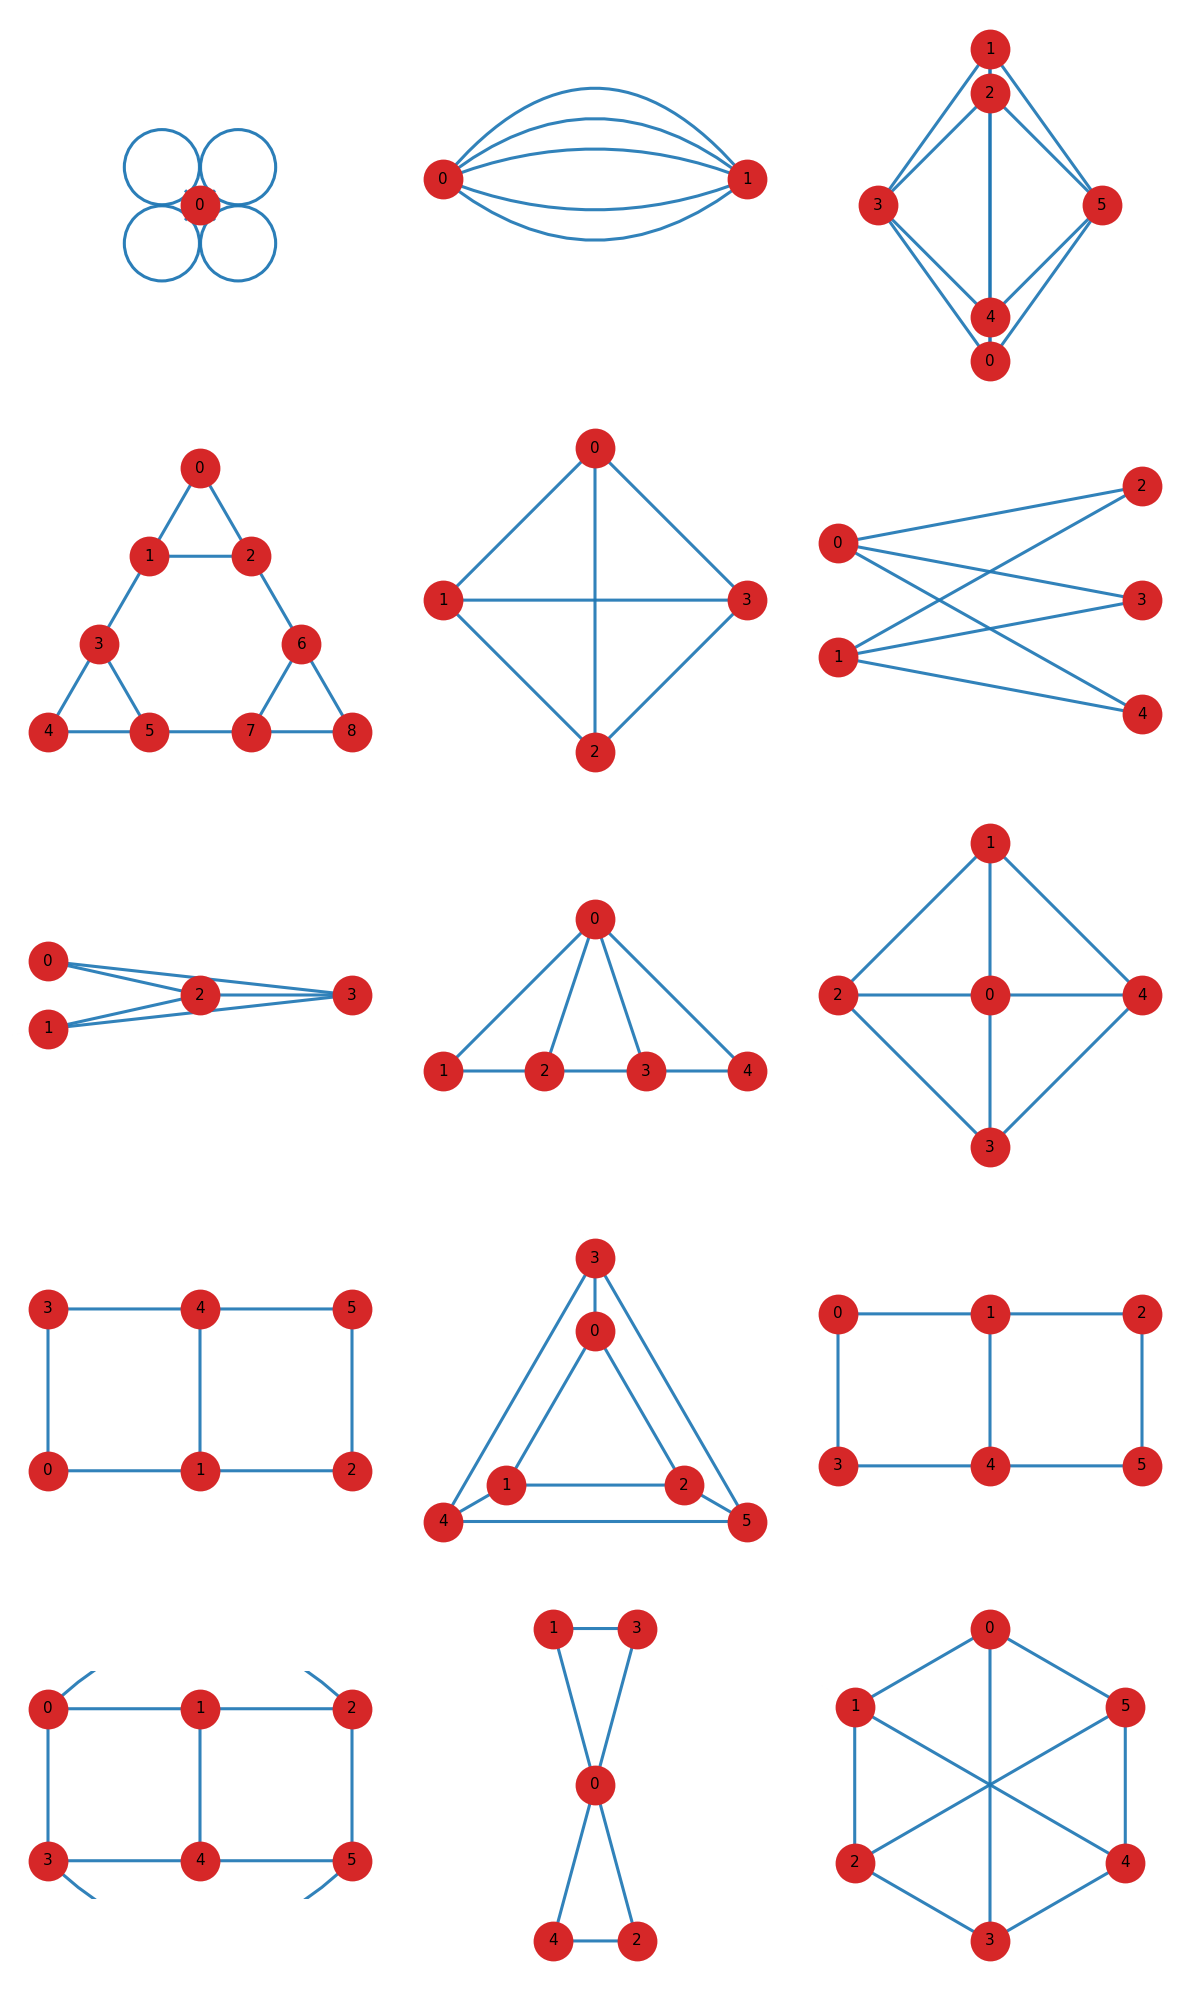

panel 1: Bouquet with 4 loops  {'nodes': 1, 'edges': 4, 'loops': 4, 'max_multiplicity': 4}
Upsilon(Bouquet with 4 loops; Y) = -Y**4 - 4*Y**3 - 10*Y**2 - 16*Y - 19 - 16/Y - 10/Y**2 - 4/Y**3 - 1/Y**4
Upsilon_sigma(Bouquet with 4 loops; sigma) = -sigma**4

panel 2: Theta graph with 5 parallel edges  {'nodes': 2, 'edges': 5, 'loops': 0, 'max_multiplicity': 5}
Upsilon(Theta graph with 5 parallel edges; Y) = -Y**4 - 3*Y**3 - 8*Y**2 - 11*Y - 14 - 11/Y - 8/Y**2 - 3/Y**3 - 1/Y**4
Upsilon_sigma(Theta graph with 5 parallel edges; sigma) = -sigma**4 + sigma**3 - sigma**2 + sigma

panel 3: Periodic theta graph with 4 strands  {'nodes': 6, 'edges': 12, 'loops': 0, 'max_multiplicity': 1}
Upsilon(Periodic theta graph with 4 strands; Y) = Y**7 + 2*Y**6 + 13*Y**5 + 18*Y**4 + 60*Y**3 + 64*Y**2 + 125*Y + 97 + 125/Y + 64/Y**2 + 60/Y**3 + 18/Y**4 + 13/Y**5 + 2/Y**6 + Y**(-7)
Upsilon_sigma(Periodic theta graph with 4 strands; sigma) = sigma**7 - 5*sigma**6 + 15*sigma**5 - 29*sigma**4 + 40*sigma**3 - 32*sigma

In [6]:
catalog_results = {}
cols = 3
rows = math.ceil(len(NOTEBOOK_YAMADA_EXAMPLES) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
axes = np.asarray(axes).reshape(-1)

for ax, (family_name, args, label) in zip(axes, NOTEBOOK_YAMADA_EXAMPLES):
    graph, pos = build_graph_case(family_name, *args)
    plot_structured_multigraph(
        graph,
        pos,
        family_name=family_name,
        family_args=args,
        ax=ax,
        show=False,
        node_color=RED,
        node_edge_color=RED,
        edge_color=BLUE,
    )
    yamada_y = sp.expand(compute_yamada_polynomial_recursive(graph, Y))
    yamada_sigma = laurent_y_to_sigma_polynomial(yamada_y, Y, sigma).as_expr()
    catalog_results[label] = {
        "summary": graph_summary(graph),
        "Y": yamada_y,
        "sigma": sp.expand(yamada_sigma),
    }

for ax in axes[len(NOTEBOOK_YAMADA_EXAMPLES):]:
    ax.set_axis_off()

plt.tight_layout()
plt.show()

for panel_index, label in enumerate(catalog_results, start=1):
    result = catalog_results[label]
    print(f"panel {panel_index}: {label}  {result['summary']}")
    print_upsilon(label, result["Y"])
    print(f"Upsilon_sigma({label}; sigma) = {result['sigma']}")
    print()


### 4.2 Scan a parameterized family

Call the same graph-family builder repeatedly when you want to study how topology
changes with a discrete parameter.

The cylinder example below varies one parameter and stores the resulting
polynomials. You can use the same pattern for your own family by replacing the
builder and parameter range.

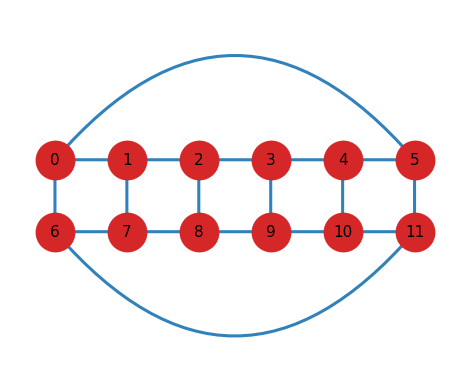

Cylinder(2,3): {'nodes': 6, 'edges': 9, 'loops': 0, 'max_multiplicity': 1}
Upsilon(Cylinder(2,3); Y) = -Y**4 + Y**3 - 3*Y**2 + 2*Y - 4 + 2/Y - 3/Y**2 + Y**(-3) - 1/Y**4
Upsilon_sigma(Cylinder(2,3); sigma) = -sigma**4 + 5*sigma**3 - 8*sigma**2 + 4*sigma

Cylinder(2,4): {'nodes': 8, 'edges': 12, 'loops': 0, 'max_multiplicity': 1}
Upsilon(Cylinder(2,4); Y) = Y**5 - 2*Y**4 + 7*Y**3 - 5*Y**2 + 14*Y - 6 + 14/Y - 5/Y**2 + 7/Y**3 - 2/Y**4 + Y**(-5)
Upsilon_sigma(Cylinder(2,4); sigma) = sigma**5 - 7*sigma**4 + 20*sigma**3 - 25*sigma**2 + 11*sigma

Cylinder(2,5): {'nodes': 10, 'edges': 15, 'loops': 0, 'max_multiplicity': 1}
Upsilon(Cylinder(2,5); Y) = -Y**6 + 3*Y**5 - 11*Y**4 + 15*Y**3 - 29*Y**2 + 27*Y - 38 + 27/Y - 29/Y**2 + 15/Y**3 - 11/Y**4 + 3/Y**5 - 1/Y**6
Upsilon_sigma(Cylinder(2,5); sigma) = -sigma**6 + 9*sigma**5 - 35*sigma**4 + 70*sigma**3 - 69*sigma**2 + 26*sigma

Cylinder(2,6): {'nodes': 12, 'edges': 18, 'loops': 0, 'max_multiplicity': 1}
Upsilon(Cylinder(2,6); Y) = Y**7 - 4*Y**6 + 16

In [7]:
cylinder_scan = []
for cols in range(3, 7):
    graph, pos = build_graph_case("cylinder", 2, cols)
    yamada_y = sp.expand(compute_yamada_polynomial_recursive(graph, Y))
    yamada_sigma = laurent_y_to_sigma_polynomial(yamada_y, Y, sigma).as_expr()
    cylinder_scan.append(
        (cols, graph_summary(graph), yamada_y, sp.expand(yamada_sigma))
    )

graph, pos = build_graph_case("cylinder", 2, 6)
plot_structured_multigraph(
    graph,
    pos,
    family_name="cylinder",
    family_args=(2, 6),
    node_color=RED,
    node_edge_color=RED,
    edge_color=BLUE,
)

for cols, summary, yamada_y, yamada_sigma in cylinder_scan:
    label = f"Cylinder(2,{cols})"
    print(f"{label}: {summary}")
    print_upsilon(label, yamada_y)
    print(f"Upsilon_sigma({label}; sigma) = {yamada_sigma}")
    print()


## 5. Inspect any catalog case interactively

`inspect_catalog_case(...)` is a small convenience wrapper around the public catalog
builder and plotting functions.

Pass the family name followed by that family's parameters. The helper then:

1. builds the graph;
2. plots it;
3. prints basic graph information;
4. computes $\Upsilon(G;Y)$; and
5. prints the corresponding $\sigma$ representation.

Use it to verify a few cases manually before generating a dataset.

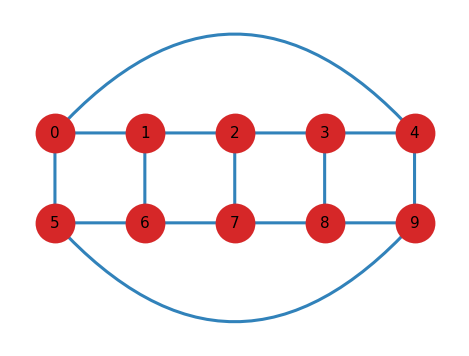

summary = {'nodes': 10, 'edges': 15, 'loops': 0, 'max_multiplicity': 1}
Upsilon(cylinder(2, 5); Y) = -Y**6 + 3*Y**5 - 11*Y**4 + 15*Y**3 - 29*Y**2 + 27*Y - 38 + 27/Y - 29/Y**2 + 15/Y**3 - 11/Y**4 + 3/Y**5 - 1/Y**6
Upsilon_sigma(cylinder(2, 5); sigma) = -sigma**6 + 9*sigma**5 - 35*sigma**4 + 70*sigma**3 - 69*sigma**2 + 26*sigma


(<networkx.classes.multigraph.MultiGraph at 0x11a895370>,
 -Y**6 + 3*Y**5 - 11*Y**4 + 15*Y**3 - 29*Y**2 + 27*Y - 38 + 27/Y - 29/Y**2 + 15/Y**3 - 11/Y**4 + 3/Y**5 - 1/Y**6,
 -sigma**6 + 9*sigma**5 - 35*sigma**4 + 70*sigma**3 - 69*sigma**2 + 26*sigma)

In [8]:
def inspect_catalog_case(family_name, *args):
    graph, pos = build_graph_case(family_name, *args)
    plot_structured_multigraph(
        graph,
        pos,
        family_name=family_name,
        family_args=args,
        node_color=RED,
        node_edge_color=RED,
        edge_color=BLUE,
    )
    yamada_y = sp.expand(compute_yamada_polynomial_recursive(graph, Y))
    yamada_sigma = sp.expand(
        laurent_y_to_sigma_polynomial(yamada_y, Y, sigma).as_expr()
    )
    print("summary =", graph_summary(graph))
    print_upsilon(f"{family_name}{args}", yamada_y)
    print(f"Upsilon_sigma({family_name}{args}; sigma) = {yamada_sigma}")
    return graph, yamada_y, yamada_sigma


# Example:
inspect_catalog_case("cylinder", 2, 5)


## 6. Test a Petersen-minor certificate for intrinsic linkedness

Graph-minor questions belong naturally in the mathematical workflow because they concern
the **abstract graph**, rather than the physical field or surface that produced a
particular embedding.

The example below starts from the extracted “Awesome” graph and asks whether it contains
the Petersen graph as a minor.

Interpret the result as follows:

- `True` gives a Petersen-minor certificate. Since the Petersen graph belongs to the
  Petersen family of forbidden minors for linkless embeddings, this is sufficient to
  establish intrinsic linkedness of the abstract graph.
- `False` does **not** establish linkless embeddability. It only says that this particular
  Petersen target was not found; other Petersen-family minors would still need to be
  checked for a complete forbidden-minor test.

The code also returns the branch sets used for the detected minor, when available.

The built-in nodal constructors define a two-band non-Hermitian Hamiltonian from a
complex polynomial $f(z,w)$.  They first return the Bloch vector

$$
\mathbf d_f(\mathbf k)
=
\left(
\operatorname{Re}f,\,
i\gamma,\,
\operatorname{Im}f
\right),
$$

and `NodalSkeleton` constructs

$$
H_f(\mathbf k;\gamma)
=
\mathbf d_f(\mathbf k)\cdot\boldsymbol{\sigma}
=
\begin{pmatrix}
\operatorname{Im}f & \operatorname{Re}f+\gamma\\
\operatorname{Re}f-\gamma & -\operatorname{Im}f
\end{pmatrix}.
$$

Unless a model explicitly overrides them,

$$
z
=
\cos(2k_z)+c
+i\left(
\cos k_x+\cos k_y+\cos k_z-m
\right),
\qquad
w
=
\sin k_x+i\sin k_y.
$$

For the “Awesome” model,

$$
f_{\mathrm{Awesome}}(z,w)
=
z\left(z^2-w^4+w\right).
$$

The extracted graph in this example uses $\gamma=0.2$ and $c=0.5$ before the abstract
minor test is applied.

The given graph contains the minor graph.
awesome graph nodes / edges = (15, 23)
degree sequence = [3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4]
Petersen minor found = True
branch-set sizes = {0: 1, 1: 2, 4: 2, 5: 1, 2: 2, 6: 1, 3: 2, 7: 1, 8: 1, 9: 1}


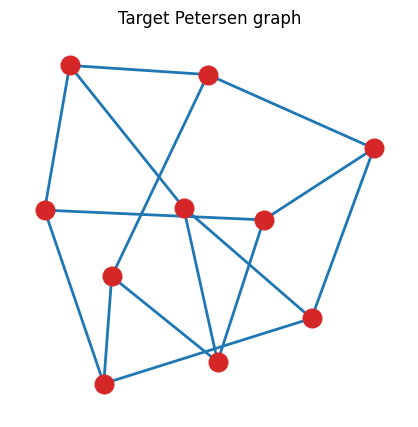

In [9]:
from knotted_graph.applications.nodal import NodalSkeleton
from knotted_graph.applications.nodal.models import (
    awesome_bloch_vector,
    threelink_bloch_vector,
)


awesome_minor_ske = NodalSkeleton(
    awesome_bloch_vector(
        0.2,
        k_symbols=(kx, ky, kz),
        c=0.5,
    ),
    k_symbols=(kx, ky, kz),
    dimension=300,
    axis_scale=(1.0, 1.0, 1.5),
)

awesome_minor_graph = (
    awesome_minor_ske.skeleton_graph(
        simplify=True,
        smooth_epsilon=2,
    )
)

petersen_graph = nx.petersen_graph()

minor_embedding = (
    awesome_minor_ske.check_minor(
        petersen_graph,
        awesome_minor_graph,
    )
)

print(
    "awesome graph nodes / edges =",
    (
        awesome_minor_graph.number_of_nodes(),
        awesome_minor_graph.number_of_edges(),
    ),
)
print(
    "degree sequence =",
    sorted(
        dict(
            awesome_minor_graph.degree()
        ).values()
    ),
)
print(
    "Petersen minor found =",
    bool(minor_embedding),
)

if minor_embedding:
    print(
        "branch-set sizes =",
        {
            node: len(branch_set)
            for node, branch_set
            in minor_embedding.items()
        },
    )


# Inspect the extracted embedded graph.
plot_graph_kg(
    awesome_minor_graph
).show()


# Inspect the target Petersen graph separately.
fig, ax = plt.subplots(
    figsize=(5.4, 5.0)
)

petersen_pos = nx.spring_layout(
    petersen_graph,
    seed=4,
)

nx.draw_networkx_edges(
    petersen_graph,
    pos=petersen_pos,
    ax=ax,
    edge_color=BLUE,
    width=2.0,
)

nx.draw_networkx_nodes(
    petersen_graph,
    pos=petersen_pos,
    ax=ax,
    node_color=RED,
    node_size=180,
)

ax.set_title(
    "Target Petersen graph"
)
ax.set_aspect("equal")
ax.axis("off")
plt.show()

## 7. Track planarity and connectivity during a parameter sweep

After the intrinsic-linkedness example, it is natural to inspect additional
**abstract graph diagnostics** across a parameter family.

For each parameter value, this example:

1. keeps the complete extracted surface;
2. extracts the embedded spatial graph;
3. records graph connectivity information; and
4. tests whether the underlying abstract graph is planar.

The distinction is important:

- **graph connectivity** concerns how the abstract graph is connected;
- **abstract planarity** asks whether that graph can be drawn in the plane without
  crossings;
- the topology of the specific embedding in $\mathbb{R}^3$ is a separate question.

Therefore a planar abstract graph is not automatically a topologically trivial
three-dimensional embedding.

The built-in nodal constructors define a two-band non-Hermitian Hamiltonian from a
complex polynomial $f(z,w)$.  They first return the Bloch vector

$$
\mathbf d_f(\mathbf k)
=
\left(
\operatorname{Re}f,\,
i\gamma,\,
\operatorname{Im}f
\right),
$$

and `NodalSkeleton` constructs

$$
H_f(\mathbf k;\gamma)
=
\mathbf d_f(\mathbf k)\cdot\boldsymbol{\sigma}
=
\begin{pmatrix}
\operatorname{Im}f & \operatorname{Re}f+\gamma\\
\operatorname{Re}f-\gamma & -\operatorname{Im}f
\end{pmatrix}.
$$

Unless a model explicitly overrides them,

$$
z
=
\cos(2k_z)+c
+i\left(
\cos k_x+\cos k_y+\cos k_z-m
\right),
\qquad
w
=
\sin k_x+i\sin k_y.
$$

For the three-link model,

$$
f_{\mathrm{3L}}(z,w)
=
z\left(z^2-w^2\right),
\qquad
c=0.5,\quad m=2.
$$

In [11]:
three_link_planarity_records = []
for gamma in (0.116, 0.41, 0.5):
    ske_three = NodalSkeleton(
        threelink_bloch_vector(gamma, k_symbols=(kx, ky, kz)),
        k_symbols=(kx, ky, kz),
        dimension=200,
        axis_scale=(1.0, 1.0, 1.5),
    )
    surface_three = ske_three.exceptional_surface_pv
    graph_three = ske_three.skeleton_graph(simplify=True, smooth_epsilon=2)
    planar_three = nx.check_planarity(nx.Graph(graph_three))[0]
    three_link_planarity_records.append(
        (gamma, surface_three, graph_three, planar_three)
    )
    print(f"gamma = {gamma}")
    print_surface_summary("  full surface", surface_three)
    print(
        "  graph_nodes_edges =",
        (graph_three.number_of_nodes(), graph_three.number_of_edges()),
    )
    print("  planar =", planar_three)


gamma = 0.116
  full surface: 34544 points, 69104 cells
  connected components = 1
  graph_nodes_edges = (8, 12)
  planar = False
gamma = 0.41
  full surface: 62660 points, 125332 cells
  connected components = 1
  graph_nodes_edges = (6, 9)
  planar = False
gamma = 0.5
  full surface: 66432 points, 132868 cells
  connected components = 1
  graph_nodes_edges = (2, 3)
  planar = True


In [12]:
fig = make_subplots(
    rows=2,
    cols=3,
    specs=[
        [{"type": "scene"} for _ in range(3)],
        [{"type": "scene"} for _ in range(3)],
    ],
    horizontal_spacing=0.01,
    vertical_spacing=0.02,
)
for col, (
    gamma,
    surface_three,
    graph_three,
    planar_three,
) in enumerate(three_link_planarity_records, start=1):
    add_surface_trace(fig, surface_three, row=1, col=col, opacity=0.46)
    add_graph_traces(fig, graph_three, row=2, col=col)
style_plotly_scenes(fig, 6, width=1080, height=720).show()


## 8. Generate a small example Yamada dataset

Dataset generation can become expensive very quickly because exact Yamada calculations
grow with graph complexity.

For the user guide, the live calculation is therefore intentionally **small**: only six
simple catalog cases are evaluated. Its purpose is to show the dataset-generation
workflow without making a new user wait for a large exact-computation sweep.

Each generated row stores:

- `graph_name`;
- `varying_params`;
- `yamada`;
- `yamada_sigma`.

A larger precomputed dataset is supplied as
`structured_graph_yamada_dataset.csv` in the **same folder as this notebook** and is
loaded in the next section.

In [13]:
import csv


# Six deliberately small cases for a fast tutorial run.
DEMO_YAMADA_SWEEPS = {
    "periodic_theta": [
        (2,),
        (3,),
    ],
    "fan": [
        (2,),
        (3,),
    ],
    "ladder": [
        (2,),
        (3,),
    ],
}

planned_demo_row_count = sum(
    len(args_list)
    for args_list in DEMO_YAMADA_SWEEPS.values()
)


def compute_demo_yamada_dataset(output_path=None):
    """Compute a small exact dataset suitable for a quick tutorial run."""
    fieldnames = [
        "graph_name",
        "varying_params",
        "yamada",
        "yamada_sigma",
    ]

    rows = []

    print(
        "Planned tutorial rows =",
        planned_demo_row_count,
    )

    for family_name, args_list in DEMO_YAMADA_SWEEPS.items():
        builder = (
            GRAPH_FAMILY_CATALOG[
                family_name
            ].builder
        )

        for args in args_list:
            graph = builder(*args)

            yamada_expr = sp.expand(
                compute_yamada_polynomial_recursive(
                    graph,
                    Y,
                )
            )

            yamada_sigma_expr = (
                laurent_y_to_sigma_polynomial(
                    yamada_expr,
                    Y,
                    sigma,
                )
                .as_expr()
            )

            row = {
                "graph_name": family_name,
                "varying_params": repr(
                    tuple(args)
                ),
                "yamada": sp.sstr(
                    yamada_expr
                ),
                "yamada_sigma": sp.sstr(
                    yamada_sigma_expr
                ),
            }

            rows.append(row)

            print(
                f"{family_name:18s} "
                f"{row['varying_params']:8s} "
                f"{row['yamada']}"
            )

    if output_path is not None:
        output_path = Path(
            output_path
        )

        with output_path.open(
            "w",
            newline="",
            encoding="utf-8",
        ) as handle:
            writer = csv.DictWriter(
                handle,
                fieldnames=fieldnames,
            )
            writer.writeheader()
            writer.writerows(rows)

        print(
            f"\nSaved demo dataset to "
            f"{output_path}"
        )

    return rows

### 8.1 Run the small demonstration

This cell computes only six small graph cases, so it is suitable for a first tutorial
run.

The demo is intentionally separate from the supplied full CSV. Running this cell will
not overwrite `structured_graph_yamada_dataset.csv`.

In [14]:
demo_yamada_dataset = (
    compute_demo_yamada_dataset()
)

print(
    f"\nComputed "
    f"{len(demo_yamada_dataset)} "
    f"tutorial rows."
)

demo_yamada_dataset

Planned tutorial rows = 6
periodic_theta     (2,)     Y**3 + 2*Y**2 + 5*Y + 5 + 5/Y + 2/Y**2 + Y**(-3)
periodic_theta     (3,)     Y**5 + Y**4 + 7*Y**3 + 5*Y**2 + 15*Y + 8 + 15/Y + 5/Y**2 + 7/Y**3 + Y**(-4) + Y**(-5)
fan                (2,)     Y + 1 + 1/Y
fan                (3,)     -Y**2 - Y - 2 - 1/Y - 1/Y**2
ladder             (2,)     Y + 1 + 1/Y
ladder             (3,)     -Y**2 - Y - 2 - 1/Y - 1/Y**2

Computed 6 tutorial rows.


[{'graph_name': 'periodic_theta',
  'varying_params': '(2,)',
  'yamada': 'Y**3 + 2*Y**2 + 5*Y + 5 + 5/Y + 2/Y**2 + Y**(-3)',
  'yamada_sigma': 'sigma**3 - sigma**2 + sigma'},
 {'graph_name': 'periodic_theta',
  'varying_params': '(3,)',
  'yamada': 'Y**5 + Y**4 + 7*Y**3 + 5*Y**2 + 15*Y + 8 + 15/Y + 5/Y**2 + 7/Y**3 + Y**(-4) + Y**(-5)',
  'yamada_sigma': 'sigma**5 - 4*sigma**4 + 8*sigma**3 - 9*sigma**2 + 4*sigma'},
 {'graph_name': 'fan',
  'varying_params': '(2,)',
  'yamada': 'Y + 1 + 1/Y',
  'yamada_sigma': 'sigma'},
 {'graph_name': 'fan',
  'varying_params': '(3,)',
  'yamada': '-Y**2 - Y - 2 - 1/Y - 1/Y**2',
  'yamada_sigma': '-sigma**2 + sigma'},
 {'graph_name': 'ladder',
  'varying_params': '(2,)',
  'yamada': 'Y + 1 + 1/Y',
  'yamada_sigma': 'sigma'},
 {'graph_name': 'ladder',
  'varying_params': '(3,)',
  'yamada': '-Y**2 - Y - 2 - 1/Y - 1/Y**2',
  'yamada_sigma': '-sigma**2 + sigma'}]

## 9. Inspect the supplied structured-graph Yamada dataset

For broader coverage, use the supplied
`structured_graph_yamada_dataset.csv` rather than recomputing a large exact dataset
during the tutorial.

The CSV is distributed in the **same `applications/` folder** as this notebook. It
contains the precomputed columns

- `graph_name`;
- `varying_params`;
- `yamada`; and
- `yamada_sigma`.

The cell below locates that file, reports its size, and displays the **complete CSV in a
scrollable table**.

In [15]:
import csv
import html
from IPython.display import HTML


def find_local_structured_dataset():
    """Locate the CSV distributed beside this notebook."""
    filename = (
        "structured_graph_yamada_dataset.csv"
    )

    candidates = [
        Path.cwd() / filename,
        PROJECT_ROOT
        / "doc"
        / "user_guide"
        / "applications"
        / filename,
        PROJECT_ROOT
        / "doc"
        / "applications"
        / filename,
    ]

    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()

    # Fallback for a differently named documentation folder.
    matches = list(
        PROJECT_ROOT.glob(
            f"**/applications/{filename}"
        )
    )

    if len(matches) == 1:
        return matches[0].resolve()

    if len(matches) > 1:
        raise FileNotFoundError(
            "More than one structured_graph_yamada_dataset.csv "
            "was found. Run this notebook from its applications "
            "folder so the intended file is unambiguous."
        )

    raise FileNotFoundError(
        "Could not find structured_graph_yamada_dataset.csv. "
        "Keep the CSV in the same applications folder as "
        "02_mathematics_applications.ipynb."
    )


dataset_path = (
    find_local_structured_dataset()
)

with dataset_path.open(
    newline="",
    encoding="utf-8",
) as handle:
    reader = csv.DictReader(
        handle
    )
    stored_rows = list(
        reader
    )
    stored_columns = list(
        reader.fieldnames or []
    )

print(
    "dataset path =",
    dataset_path,
)
print(
    "stored rows =",
    len(stored_rows),
)
print(
    "columns =",
    stored_columns,
)


def _csv_html_table(
    rows,
    columns,
):
    header = "".join(
        f"<th>{html.escape(column)}</th>"
        for column in columns
    )

    body_rows = []

    for row in rows:
        cells = "".join(
            "<td style='vertical-align:top;"
            "padding:4px 8px;"
            "white-space:pre-wrap;'>"
            f"{html.escape(str(row.get(column, '')))}"
            "</td>"
            for column in columns
        )

        body_rows.append(
            f"<tr>{cells}</tr>"
        )

    return f"""
    <div style="
        max-height:620px;
        overflow:auto;
        border:1px solid #ddd;
    ">
      <table style="
          border-collapse:collapse;
          width:100%;
          font-family:monospace;
          font-size:12px;
      ">
        <thead style="
            position:sticky;
            top:0;
            background:white;
            z-index:1;
        ">
          <tr>{header}</tr>
        </thead>
        <tbody>
          {''.join(body_rows)}
        </tbody>
      </table>
    </div>
    """


display(
    HTML(
        _csv_html_table(
            stored_rows,
            stored_columns,
        )
    )
)

dataset path = /Users/hakanakgun/Desktop/Projects/ProfLeeProjects/Knotted_graph_code_paper/Latest_Workplace/User_guide/applications/structured_graph_yamada_dataset.csv
stored rows = 87
columns = ['graph_name', 'varying_params', 'yamada', 'yamada_sigma']


graph_name,varying_params,yamada,yamada_sigma
periodic_theta,"(1,)",0,0
periodic_theta,"(2,)",Y**3 + 2*Y**2 + 5*Y + 5 + 5/Y + 2/Y**2 + Y**(-3),sigma**3 - sigma**2 + sigma
periodic_theta,"(3,)",Y**5 + Y**4 + 7*Y**3 + 5*Y**2 + 15*Y + 8 + 15/Y + 5/Y**2 + 7/Y**3 + Y**(-4) + Y**(-5),sigma**5 - 4*sigma**4 + 8*sigma**3 - 9*sigma**2 + 4*sigma
periodic_theta,"(4,)",Y**7 + 2*Y**6 + 13*Y**5 + 18*Y**4 + 60*Y**3 + 64*Y**2 + 125*Y + 97 + 125/Y + 64/Y**2 + 60/Y**3 + 18/Y**4 + 13/Y**5 + 2/Y**6 + Y**(-7),sigma**7 - 5*sigma**6 + 15*sigma**5 - 29*sigma**4 + 40*sigma**3 - 32*sigma**2 + 11*sigma
periodic_theta,"(5,)",Y**9 + 3*Y**8 + 18*Y**7 + 36*Y**6 + 118*Y**5 + 167*Y**4 + 371*Y**3 + 396*Y**2 + 638*Y + 524 + 638/Y + 396/Y**2 + 371/Y**3 + 167/Y**4 + 118/Y**5 + 36/Y**6 + 18/Y**7 + 3/Y**8 + Y**(-9),sigma**9 - 6*sigma**8 + 21*sigma**7 - 51*sigma**6 + 94*sigma**5 - 135*sigma**4 + 140*sigma**3 - 90*sigma**2 + 26*sigma
periodic_theta,"(6,)",Y**11 + 4*Y**10 + 24*Y**9 + 64*Y**8 + 214*Y**7 + 416*Y**6 + 982*Y**5 + 1462*Y**4 + 2607*Y**3 + 3052*Y**2 + 4208*Y + 3893 + 4208/Y + 3052/Y**2 + 2607/Y**3 + 1462/Y**4 + 982/Y**5 + 416/Y**6 + 214/Y**7 + 64/Y**8 + 24/Y**9 + 4/Y**10 + Y**(-11),sigma**11 - 7*sigma**10 + 28*sigma**9 - 78*sigma**8 + 168*sigma**7 - 292*sigma**6 + 421*sigma**5 - 487*sigma**4 + 417*sigma**3 - 227*sigma**2 + 57*sigma
periodic_theta,"(7,)",Y**13 + 5*Y**12 + 31*Y**11 + 101*Y**10 + 355*Y**9 + 848*Y**8 + 2126*Y**7 + 3922*Y**6 + 7591*Y**5 + 11143*Y**4 + 17226*Y**3 + 20506*Y**2 + 25735*Y + 25066 + 25735/Y + 20506/Y**2 + 17226/Y**3 + 11143/Y**4 + 7591/Y**5 + 3922/Y**6 + 2126/Y**7 + 848/Y**8 + 355/Y**9 + 101/Y**10 + 31/Y**11 + 5/Y**12 + Y**(-13),sigma**13 - 8*sigma**12 + 36*sigma**11 - 113*sigma**10 + 274*sigma**9 - 540*sigma**8 + 895*sigma**7 - 1274*sigma**6 + 1547*sigma**5 - 1533*sigma**4 + 1134*sigma**3 - 539*sigma**2 + 120*sigma
periodic_theta,"(8,)",Y**15 + 6*Y**14 + 39*Y**13 + 148*Y**12 + 555*Y**11 + 1542*Y**10 + 4173*Y**9 + 9050*Y**8 + 19156*Y**7 + 33544*Y**6 + 57672*Y**5 + 83172*Y**4 + 118312*Y**3 + 142120*Y**2 + 168729*Y + 169685 + 168729/Y + 142120/Y**2 + 118312/Y**3 + 83172/Y**4 + 57672/Y**5 + 33544/Y**6 + 19156/Y**7 + 9050/Y**8 + 4173/Y**9 + 1542/Y**10 + 555/Y**11 + 148/Y**12 + 39/Y**13 + 6/Y**14 + Y**(-15),sigma**15 - 9*sigma**14 + 45*sigma**13 - 157*sigma**12 + 423*sigma**11 - 927*sigma**10 + 1711*sigma**9 - 2725*sigma**8 + 3816*sigma**7 - 4720*sigma**6 + 5056*sigma**5 - 4440*sigma**4 + 2914*sigma**3 - 1234*sigma**2 + 247*sigma
periodic_theta,"(9,)",Y**17 + 7*Y**16 + 48*Y**15 + 206*Y**14 + 827*Y**13 + 2586*Y**12 + 7567*Y**11 + 18550*Y**10 + 42820*Y**9 + 85487*Y**8 + 161819*Y**7 + 268944*Y**6 + 426418*Y**5 + 598048*Y**4 + 803766*Y**3 + 959204*Y**2 + 1099746*Y + 1121552 + 1099746/Y + 959204/Y**2 + 803766/Y**3 + 598048/Y**4 + 426418/Y**5 + 268944/Y**6 + 161819/Y**7 + 85487/Y**8 + 42820/Y**9 + 18550/Y**10 + 7567/Y**11 + 2586/Y**12 + 827/Y**13 + 206/Y**14 + 48/Y**15 + 7/Y**16 + Y**(-17),sigma**17 - 10*sigma**16 + 55*sigma**15 - 211*sigma**14 + 625*sigma**13 - 1507*sigma**12 + 3061*sigma**11 - 5365*sigma**10 + 8270*sigma**9 - 11391*sigma**8 + 14154*sigma**7 - 15786*sigma**6 + 15324*sigma**5 - 12174*sigma**4 + 7212*sigma**3 - 2760*sigma**2 + 502*sigma
periodic_theta,"(10,)",Y**19 + 8*Y**18 + 58*Y**17 + 276*Y**16 + 1185*Y**15 + 4086*Y**14 + 12888*Y**13 + 34908*Y**12 + 87486*Y**11 + 194112*Y**10 + 401979*Y**9 + 748702*Y**8 + 1310212*Y**7 + 2079774*Y**6 + 3117335*Y**5 + 4257764*Y**4 + 5509917*Y**3 + 6513082*Y**2 + 7308365*Y + 7498825 + 7308365/Y + 6513082/Y**2 + 5509917/Y**3 + 4257764/Y**4 + 3117335/Y**5 + 2079774/Y**6 + 1310212/Y**7 + 748702/Y**8 + 401979/Y**9 + 194112/Y**10 + 87486/Y**11 + 34908/Y**12 + 12888/Y**13 + 4086/Y**14 + 1185/Y**15 + 276/Y**16 + 58/Y**17 + 8/Y**18 + Y**(-19),sigma**19 - 11*sigma**18 + 66*sigma**17 - 276*sigma**16 + 891*sigma**15 - 2343*sigma**14 + 5193*sigma**13 - 9933*sigma**12 + 16698*sigma**11 - 25046*sigma**10 + 33979*sigma**9 - 42149*sigma**8 + 47954*sigma**7 - 49334*sigma**6 + 44120*sigma**5 - 32132*sigma**4 + 1738

## 10. Use PD codes with your own custom invariants

`KnottedGraph` does not need to implement every invariant internally. A useful extension
pattern is

$$
G\subset\mathbb{R}^3
\longrightarrow
\texttt{PDCode}
\longrightarrow
\text{user-defined invariant}.
$$

This section demonstrates that pattern with **six classical knot embeddings** and two
well-known knot invariants:

1. the **Alexander polynomial** $\Delta_K(t)$; and
2. the **Jones polynomial** $V_K(q)$.

The invariant functions below are **not library functions**. They are deliberately
defined inside this notebook to show how a user can consume the diagram representation
produced by `KnottedGraph`.

### Scope of this example

Alexander and Jones polynomials are invariants of **knots and links**, not arbitrary
spatial graphs with junctions of valence $>2$. Therefore the six examples below are
closed curves represented as one-loop `MultiGraph` embeddings.

For orientation-sensitive calculations we use the `PDCode` **processor object** rather
than only the printed string. After `processor.compute(...)`, it contains

- `processor.crossings`: cyclic crossing data, with positions $0/2$ the over-strand;
- `processor.arcs`: directed arc endpoints; and
- `processor.vertices`: the projected graph vertices.

The printed `V[...] ; X[...]` string is still shown for inspection, but the processor is
the richer interface for building new invariants.

Conventions used below:

- $\Delta_K(t)$ is normalized up to its usual unit ambiguity $\pm t^m$ by shifting the
  lowest exponent to zero and choosing a positive constant term;
- $V_{\bigcirc}(q)=1$, with the Kauffman-bracket substitution $q=A^{-4}$.

Original references:

- J. W. Alexander, *Topological invariants of knots and links*,
  Trans. Amer. Math. Soc. **30** (1928), 275–306,
  https://doi.org/10.1090/S0002-9947-1928-1501429-1
- V. F. R. Jones, *A polynomial invariant for knots via von Neumann algebras*,
  Bull. Amer. Math. Soc. **12** (1985), 103–111,
  https://doi.org/10.1090/S0273-0979-1985-15304-2

In [16]:
def closed_curve_graph(points):
    """Store one closed curve as a one-loop embedded MultiGraph."""
    points = np.asarray(points, dtype=float)

    if not np.allclose(
        points[0],
        points[-1],
    ):
        points = np.vstack(
            [points, points[0]]
        )
    else:
        points[-1] = points[0]

    graph = nx.MultiGraph()
    graph.add_node(
        0,
        pos=points[0].copy(),
    )
    graph.add_edge(
        0,
        0,
        pts=points,
    )
    return graph


def torus_knot_curve(
    p,
    q,
    *,
    samples=500,
    major_radius=3.0,
    minor_radius=1.0,
):
    """A reproducible positive-(p,q) torus-knot embedding."""
    u = np.linspace(
        0.0,
        2.0 * np.pi,
        samples,
    )

    return np.column_stack(
        [
            (
                major_radius
                + minor_radius
                * np.cos(q * u)
            )
            * np.cos(p * u),
            (
                major_radius
                + minor_radius
                * np.cos(q * u)
            )
            * np.sin(p * u),
            -minor_radius
            * np.sin(q * u),
        ]
    )


def figure_eight_curve(
    *,
    samples=500,
):
    """A standard embedding of the figure-eight knot."""
    u = np.linspace(
        0.0,
        2.0 * np.pi,
        samples,
    )

    return np.column_stack(
        [
            (
                2.0
                + np.cos(2.0 * u)
            )
            * np.cos(3.0 * u),
            (
                2.0
                + np.cos(2.0 * u)
            )
            * np.sin(3.0 * u),
            np.sin(4.0 * u),
        ]
    )


classical_knot_examples = {
    "Unknot": closed_curve_graph(
        torus_knot_curve(1, 1)
    ),
    "Trefoil $3_1$": closed_curve_graph(
        torus_knot_curve(2, 3)
    ),
    "Figure-eight $4_1$": closed_curve_graph(
        figure_eight_curve()
    ),
    "Cinquefoil $5_1$": closed_curve_graph(
        torus_knot_curve(2, 5)
    ),
    "Septafoil $7_1$": closed_curve_graph(
        torus_knot_curve(2, 7)
    ),
    "$8_{19}=T(3,4)$": closed_curve_graph(
        torus_knot_curve(3, 4)
    ),
}

print(
    "created",
    len(classical_knot_examples),
    "embedded knot examples",
)

created 6 embedded knot examples


In [17]:
fig = make_subplots(
    rows=2,
    cols=3,
    specs=[
        [
            {"type": "scene"},
            {"type": "scene"},
            {"type": "scene"},
        ],
        [
            {"type": "scene"},
            {"type": "scene"},
            {"type": "scene"},
        ],
    ],
    subplot_titles=list(
        classical_knot_examples
    ),
)

for index, graph in enumerate(
    classical_knot_examples.values()
):
    row = index // 3 + 1
    col = index % 3 + 1

    add_graph_traces(
        fig,
        graph,
        row=row,
        col=col,
    )

style_plotly_scenes(
    fig,
    6,
    width=1080,
    height=720,
)

fig.show()

### 10.1 Generate six PD codes with `KnottedGraph`

The next cell performs the projection itself. No PD code is typed by hand.

Each 3D embedding is passed to

```python
processor = PDCode(graph)
pd_code = processor.compute(...)
```

using the same fixed projection angles for reproducibility. The resulting PD strings are
then retained together with their processor objects for the custom calculations below.

In [18]:
from IPython.display import Markdown


classical_pd_examples = {}

for name, graph in classical_knot_examples.items():
    processor = PDCode(graph)

    pd_code = processor.compute(
        rotation_angles=(
            0.0,
            0.0,
            0.0,
        ),
        rotation_order="ZYX",
    )

    classical_pd_examples[name] = {
        "graph": graph,
        "processor": processor,
        "pd_code": pd_code,
        "crossings": len(
            processor.crossings
        ),
    }


pd_lines = [
    "| Example | Crossings | PD code generated by `KnottedGraph` |",
    "| --- | ---: | --- |",
]

for name, record in classical_pd_examples.items():
    pd_lines.append(
        f"| {name} "
        f"| {record['crossings']} "
        f"| `{record['pd_code']}` |"
    )

display(
    Markdown(
        "\n".join(pd_lines)
    )
)

| Example | Crossings | PD code generated by `KnottedGraph` |
| --- | ---: | --- |
| Unknot | 0 | `V[0,0]` |
| Trefoil $3_1$ | 3 | `V[6,0];X[5,2,6,3];X[3,0,4,1];X[2,5,1,4]` |
| Figure-eight $4_1$ | 4 | `V[8,0];X[1,3,0,4];X[4,8,5,7];X[2,5,3,6];X[7,2,6,1]` |
| Cinquefoil $5_1$ | 5 | `V[10,0];X[9,4,10,5];X[8,3,7,2];X[4,9,3,8];X[1,6,2,7];X[5,0,6,1]` |
| Septafoil $7_1$ | 7 | `V[14,0];X[4,11,3,10];X[13,6,14,7];X[9,2,10,3];X[12,5,11,4];X[7,0,8,1];X[1,8,2,9];X[6,13,5,12]` |
| $8_{19}=T(3,4)$ | 8 | `V[16,0];X[8,13,7,12];X[3,14,2,13];X[4,9,3,8];X[6,1,7,2];X[15,10,14,9];X[10,5,11,6];X[15,4,16,5];X[11,0,12,1]` |

### 10.2 Define a custom Jones polynomial from the PD representation

This implementation is intentionally self-contained.

For every crossing, `KnottedGraph` has already determined the cyclic order and
over/under information. We perform the two Kauffman smoothings, count the resulting
loops, form the bracket polynomial, and finally normalize by the writhe.

For a diagram with $c$ crossings this direct teaching implementation enumerates $2^c$
states, so it is appropriate for modest examples rather than very large diagrams.

In [19]:
import itertools


A_bracket = sp.Symbol("A")
q_jones = sp.Symbol("q")


class _UnionFind:
    def __init__(
        self,
        items,
    ):
        self.parent = {
            item: item
            for item in items
        }

    def find(
        self,
        item,
    ):
        parent = self.parent[item]

        if parent != item:
            self.parent[item] = (
                self.find(parent)
            )

        return self.parent[item]

    def union(
        self,
        left,
        right,
    ):
        left_root = self.find(left)
        right_root = self.find(right)

        if left_root != right_root:
            self.parent[right_root] = (
                left_root
            )


def _pd_port_for_arc_at(
    processor,
    arc_id,
    endpoint_type,
    endpoint_id,
):
    arc = processor.arcs[arc_id]

    if (
        arc.start_type == endpoint_type
        and arc.start_id == endpoint_id
    ):
        return (
            arc_id,
            "s",
        )

    if (
        arc.end_type == endpoint_type
        and arc.end_id == endpoint_id
    ):
        return (
            arc_id,
            "e",
        )

    raise ValueError(
        "Arc is not incident to the requested "
        "PD endpoint."
    )


def _crossing_ports(
    processor,
    crossing_id,
):
    crossing = (
        processor.crossings[
            crossing_id
        ]
    )

    return [
        _pd_port_for_arc_at(
            processor,
            arc_id,
            "x",
            crossing_id,
        )
        for arc_id
        in crossing.ccw_ordered_arcs
    ]


def _vertex_ports(
    processor,
    vertex_id,
):
    ports = []

    for arc_id, arc in (
        processor.arcs.items()
    ):
        if (
            arc.start_type == "v"
            and arc.start_id == vertex_id
        ):
            ports.append(
                (
                    arc_id,
                    "s",
                )
            )

        if (
            arc.end_type == "v"
            and arc.end_id == vertex_id
        ):
            ports.append(
                (
                    arc_id,
                    "e",
                )
            )

    return ports


def crossing_sign_from_pd(
    processor,
    crossing_id,
):
    """Return +1 or -1 using only oriented PD combinatorics."""
    ordered = (
        processor.crossings[
            crossing_id
        ].ccw_ordered_arcs
    )

    incoming_positions = []

    for position, arc_id in enumerate(
        ordered
    ):
        arc = processor.arcs[
            arc_id
        ]

        if (
            arc.end_type == "x"
            and arc.end_id
            == crossing_id
        ):
            incoming_positions.append(
                position
            )

    over_in = next(
        position
        for position
        in incoming_positions
        if position in (0, 2)
    )
    under_in = next(
        position
        for position
        in incoming_positions
        if position in (1, 3)
    )

    delta = (
        under_in
        - over_in
    ) % 4

    if delta == 1:
        return 1

    if delta == 3:
        return -1

    raise ValueError(
        "Degenerate oriented crossing."
    )


def writhe_from_pd(
    processor,
):
    return sum(
        crossing_sign_from_pd(
            processor,
            crossing_id,
        )
        for crossing_id
        in processor.crossings
    )


def kauffman_bracket_from_pd(
    processor,
    A=A_bracket,
):
    """Compute <D> with <unknot>=1 from a KnottedGraph PD processor."""
    crossing_ids = list(
        processor.crossings
    )

    all_ports = [
        (
            arc_id,
            side,
        )
        for arc_id
        in processor.arcs
        for side
        in ("s", "e")
    ]

    if not all_ports:
        return sp.Integer(1)

    loop_factor = (
        -A**2
        - A**-2
    )
    total = sp.Integer(0)

    for state in itertools.product(
        (0, 1),
        repeat=len(
            crossing_ids
        ),
    ):
        union_find = _UnionFind(
            all_ports
        )

        for arc_id in processor.arcs:
            union_find.union(
                (
                    arc_id,
                    "s",
                ),
                (
                    arc_id,
                    "e",
                ),
            )

        for vertex_id in processor.vertices:
            ports = _vertex_ports(
                processor,
                vertex_id,
            )

            if len(ports) != 2:
                raise ValueError(
                    "This Jones example expects a "
                    "knot/link diagram with valence-2 "
                    f"vertices; vertex {vertex_id} "
                    f"has {len(ports)} half-edges."
                )

            union_find.union(
                ports[0],
                ports[1],
            )

        n_A = 0

        for (
            crossing_id,
            smoothing,
        ) in zip(
            crossing_ids,
            state,
        ):
            ports = _crossing_ports(
                processor,
                crossing_id,
            )

            if smoothing == 0:
                pairs = (
                    (0, 3),
                    (1, 2),
                )
                n_A += 1
            else:
                pairs = (
                    (0, 1),
                    (2, 3),
                )

            for left, right in pairs:
                union_find.union(
                    ports[left],
                    ports[right],
                )

        loop_count = len(
            {
                union_find.find(port)
                for port
                in all_ports
            }
        )

        n_B = (
            len(crossing_ids)
            - n_A
        )

        total += (
            A**(
                n_A
                - n_B
            )
            * loop_factor**(
                loop_count
                - 1
            )
        )

    return sp.expand(total)


def jones_polynomial_from_pd(
    processor,
    q=q_jones,
):
    """Jones polynomial with V_unknot(q)=1 and q=A^(-4)."""
    bracket = (
        kauffman_bracket_from_pd(
            processor,
            A=A_bracket,
        )
    )

    writhe = writhe_from_pd(
        processor
    )

    normalized_A = sp.expand(
        (
            -A_bracket**3
        )**(-writhe)
        * bracket
    )

    result = sp.Integer(0)

    for term in sp.Add.make_args(
        normalized_A
    ):
        coefficient, exponent = (
            term.as_coeff_exponent(
                A_bracket
            )
        )
        exponent = int(exponent)

        if exponent % 4 != 0:
            raise ValueError(
                "This compact converter is written "
                "for one-component knot examples; "
                f"encountered A^{exponent}."
            )

        result += (
            coefficient
            * q**(
                -exponent // 4
            )
        )

    return sp.expand(result)

### 10.3 Define a custom Alexander polynomial from the same PD representation

For the Alexander polynomial we construct a Wirtinger/Alexander matrix directly from
the oriented diagram.

At a crossing, the over-strand remains in one Wirtinger generator while the under-strand
is split into incoming and outgoing generators. Deleting one row and one column gives
the usual Alexander minor.

The result is defined only up to multiplication by $\pm t^m$; the helper below fixes a
consistent representative for display.

In [20]:
t_alexander = sp.Symbol("t")


def _wirtinger_generator_map(
    processor,
):
    arc_ids = list(
        processor.arcs
    )

    if not arc_ids:
        return {}, 0

    union_find = _UnionFind(
        arc_ids
    )

    for vertex_id in processor.vertices:
        incident = []

        for arc_id, arc in (
            processor.arcs.items()
        ):
            if (
                (
                    arc.start_type
                    == "v"
                    and arc.start_id
                    == vertex_id
                )
                or (
                    arc.end_type
                    == "v"
                    and arc.end_id
                    == vertex_id
                )
            ):
                incident.append(
                    arc_id
                )

        incident = list(
            dict.fromkeys(
                incident
            )
        )

        if len(incident) == 2:
            union_find.union(
                incident[0],
                incident[1],
            )
        elif len(incident) == 1:
            pass
        else:
            raise ValueError(
                "This Alexander example expects "
                "a knot/link diagram with "
                "valence-2 vertices."
            )

    for crossing in (
        processor.crossings.values()
    ):
        ordered = (
            crossing.ccw_ordered_arcs
        )

        union_find.union(
            ordered[0],
            ordered[2],
        )

    root_to_generator = {}
    arc_to_generator = {}

    for arc_id in arc_ids:
        root = union_find.find(
            arc_id
        )

        root_to_generator.setdefault(
            root,
            len(
                root_to_generator
            ),
        )

        arc_to_generator[
            arc_id
        ] = root_to_generator[
            root
        ]

    return (
        arc_to_generator,
        len(root_to_generator),
    )


def _crossing_wirtinger_data(
    processor,
    crossing_id,
    arc_to_generator,
):
    ordered = (
        processor.crossings[
            crossing_id
        ].ccw_ordered_arcs
    )

    direction = []

    for arc_id in ordered:
        arc = processor.arcs[
            arc_id
        ]

        if (
            arc.start_type == "x"
            and arc.start_id
            == crossing_id
        ):
            direction.append(
                "out"
            )
        elif (
            arc.end_type == "x"
            and arc.end_id
            == crossing_id
        ):
            direction.append(
                "in"
            )
        else:
            raise ValueError(
                "Inconsistent crossing/arc data."
            )

    over_generator = (
        arc_to_generator[
            ordered[0]
        ]
    )

    under_in = next(
        arc_to_generator[
            ordered[position]
        ]
        for position
        in (1, 3)
        if direction[
            position
        ] == "in"
    )

    under_out = next(
        arc_to_generator[
            ordered[position]
        ]
        for position
        in (1, 3)
        if direction[
            position
        ] == "out"
    )

    return (
        crossing_sign_from_pd(
            processor,
            crossing_id,
        ),
        over_generator,
        under_in,
        under_out,
    )


def _normalize_alexander(
    expression,
    t=t_alexander,
):
    expression = sp.expand(
        expression
    )

    if expression == 0:
        return expression

    exponents = [
        int(
            term.as_powers_dict().get(
                t,
                0,
            )
        )
        for term
        in sp.Add.make_args(
            expression
        )
    ]

    expression = sp.expand(
        expression
        * t**(
            -min(exponents)
        )
    )

    constant_term = (
        expression.coeff(
            t,
            0,
        )
    )

    if (
        constant_term
        .could_extract_minus_sign()
    ):
        expression = (
            -expression
        )

    return sp.expand(
        expression
    )


def alexander_polynomial_from_pd(
    processor,
    t=t_alexander,
):
    """Alexander polynomial from a one-component KnottedGraph PD diagram."""
    crossing_count = len(
        processor.crossings
    )

    if crossing_count == 0:
        return sp.Integer(1)

    (
        arc_to_generator,
        generator_count,
    ) = _wirtinger_generator_map(
        processor
    )

    if (
        generator_count
        != crossing_count
    ):
        raise ValueError(
            "This compact demonstration expects "
            "a regular one-component knot diagram. "
            f"Found {crossing_count} crossings "
            f"and {generator_count} "
            "Wirtinger generators."
        )

    matrix = sp.zeros(
        crossing_count,
        generator_count,
    )

    for row, crossing_id in enumerate(
        processor.crossings
    ):
        (
            sign,
            over,
            under_in,
            under_out,
        ) = _crossing_wirtinger_data(
            processor,
            crossing_id,
            arc_to_generator,
        )

        matrix[
            row,
            over,
        ] += (
            1
            - t
        )

        if sign > 0:
            matrix[
                row,
                under_out,
            ] += t
            matrix[
                row,
                under_in,
            ] += -1
        else:
            matrix[
                row,
                under_in,
            ] += t
            matrix[
                row,
                under_out,
            ] += -1

    minor = matrix[
        :-1,
        :-1,
    ]

    return _normalize_alexander(
        sp.det(minor),
        t=t,
    )

### 10.4 Evaluate both custom invariants on all six PD codes

The values below are calculated **from the PD representation generated above**.

The assertions make these examples executable checks: if the projection convention or
custom invariant implementation is accidentally changed, the cell fails instead of
silently displaying a different polynomial.

In [21]:
expected_custom_invariants = {
    "Unknot": {
        "crossings": 0,
        "alexander": sp.Integer(1),
        "jones": sp.Integer(1),
    },
    "Trefoil $3_1$": {
        "crossings": 3,
        "alexander": (
            t_alexander**2
            - t_alexander
            + 1
        ),
        "jones": (
            q_jones
            + q_jones**3
            - q_jones**4
        ),
    },
    "Figure-eight $4_1$": {
        "crossings": 4,
        "alexander": (
            t_alexander**2
            - 3 * t_alexander
            + 1
        ),
        "jones": (
            q_jones**2
            - q_jones
            + 1
            - q_jones**-1
            + q_jones**-2
        ),
    },
    "Cinquefoil $5_1$": {
        "crossings": 5,
        "alexander": (
            t_alexander**4
            - t_alexander**3
            + t_alexander**2
            - t_alexander
            + 1
        ),
        "jones": (
            q_jones**2
            + q_jones**4
            - q_jones**5
            + q_jones**6
            - q_jones**7
        ),
    },
    "Septafoil $7_1$": {
        "crossings": 7,
        "alexander": (
            t_alexander**6
            - t_alexander**5
            + t_alexander**4
            - t_alexander**3
            + t_alexander**2
            - t_alexander
            + 1
        ),
        "jones": (
            q_jones**3
            + q_jones**5
            - q_jones**6
            + q_jones**7
            - q_jones**8
            + q_jones**9
            - q_jones**10
        ),
    },
    "$8_{19}=T(3,4)$": {
        "crossings": 8,
        "alexander": (
            t_alexander**6
            - t_alexander**5
            + t_alexander**3
            - t_alexander
            + 1
        ),
        "jones": (
            q_jones**3
            + q_jones**5
            - q_jones**8
        ),
    },
}


custom_invariant_rows = []

for name, record in (
    classical_pd_examples.items()
):
    processor = record[
        "processor"
    ]

    alexander = (
        alexander_polynomial_from_pd(
            processor,
            t=t_alexander,
        )
    )

    jones = (
        jones_polynomial_from_pd(
            processor,
            q=q_jones,
        )
    )

    expected = (
        expected_custom_invariants[
            name
        ]
    )

    assert (
        record["crossings"]
        == expected["crossings"]
    )

    assert sp.simplify(
        alexander
        - expected["alexander"]
    ) == 0

    assert sp.simplify(
        jones
        - expected["jones"]
    ) == 0

    custom_invariant_rows.append(
        {
            "name": name,
            "crossings": record[
                "crossings"
            ],
            "pd_code": record[
                "pd_code"
            ],
            "alexander": alexander,
            "jones": jones,
        }
    )


result_lines = [
    "| Example | $c$ | Alexander $\\Delta_K(t)$ | Jones $V_K(q)$ |",
    "| --- | ---: | --- | --- |",
]

for row in custom_invariant_rows:
    result_lines.append(
        f"| {row['name']} "
        f"| {row['crossings']} "
        f"| ${sp.latex(row['alexander'])}$ "
        f"| ${sp.latex(row['jones'])}$ |"
    )

display(
    Markdown(
        "\n".join(
            result_lines
        )
    )
)

print(
    "all six custom-invariant checks passed"
)

| Example | $c$ | Alexander $\Delta_K(t)$ | Jones $V_K(q)$ |
| --- | ---: | --- | --- |
| Unknot | 0 | $1$ | $1$ |
| Trefoil $3_1$ | 3 | $t^{2} - t + 1$ | $- q^{4} + q^{3} + q$ |
| Figure-eight $4_1$ | 4 | $t^{2} - 3 t + 1$ | $q^{2} - q + 1 - \frac{1}{q} + \frac{1}{q^{2}}$ |
| Cinquefoil $5_1$ | 5 | $t^{4} - t^{3} + t^{2} - t + 1$ | $- q^{7} + q^{6} - q^{5} + q^{4} + q^{2}$ |
| Septafoil $7_1$ | 7 | $t^{6} - t^{5} + t^{4} - t^{3} + t^{2} - t + 1$ | $- q^{10} + q^{9} - q^{8} + q^{7} - q^{6} + q^{5} + q^{3}$ |
| $8_{19}=T(3,4)$ | 8 | $t^{6} - t^{5} + t^{3} - t + 1$ | $- q^{8} + q^{5} + q^{3}$ |

all six custom-invariant checks passed


### 10.5 The invariant should not depend on which regular projection is used

A useful check for a custom PD-code consumer is to rotate the **same spatial embedding**,
obtain different projections, and verify that the invariant remains unchanged.

Below the trefoil is evaluated from four projections. The PD strings may be ordered
differently, but the Alexander and Jones polynomials agree.

In [22]:
trefoil_graph = (
    classical_knot_examples[
        "Trefoil $3_1$"
    ]
)

trefoil_angles = [
    (0.0, 0.0, 0.0),
    (19.0, 27.0, 0.0),
    (43.0, 11.0, 0.0),
    (71.0, 38.0, 0.0),
]

trefoil_projection_results = []

for angles in trefoil_angles:
    processor = PDCode(
        trefoil_graph
    )

    pd_code = processor.compute(
        rotation_angles=angles,
        rotation_order="ZYX",
    )

    alexander = (
        alexander_polynomial_from_pd(
            processor
        )
    )

    jones = (
        jones_polynomial_from_pd(
            processor
        )
    )

    trefoil_projection_results.append(
        (
            angles,
            len(
                processor.crossings
            ),
            pd_code,
            alexander,
            jones,
        )
    )


reference_alexander = (
    trefoil_projection_results[
        0
    ][3]
)
reference_jones = (
    trefoil_projection_results[
        0
    ][4]
)

for (
    _,
    _,
    _,
    alexander,
    jones,
) in trefoil_projection_results:
    assert sp.simplify(
        alexander
        - reference_alexander
    ) == 0

    assert sp.simplify(
        jones
        - reference_jones
    ) == 0


projection_lines = [
    "| Rotation angles | Crossings | Alexander | Jones |",
    "| --- | ---: | --- | --- |",
]

for (
    angles,
    crossings,
    _,
    alexander,
    jones,
) in trefoil_projection_results:
    projection_lines.append(
        f"| `{angles}` "
        f"| {crossings} "
        f"| ${sp.latex(alexander)}$ "
        f"| ${sp.latex(jones)}$ |"
    )

display(
    Markdown(
        "\n".join(
            projection_lines
        )
    )
)

print(
    "trefoil projection-invariance check passed"
)

| Rotation angles | Crossings | Alexander | Jones |
| --- | ---: | --- | --- |
| `(0.0, 0.0, 0.0)` | 3 | $t^{2} - t + 1$ | $- q^{4} + q^{3} + q$ |
| `(19.0, 27.0, 0.0)` | 3 | $t^{2} - t + 1$ | $- q^{4} + q^{3} + q$ |
| `(43.0, 11.0, 0.0)` | 3 | $t^{2} - t + 1$ | $- q^{4} + q^{3} + q$ |
| `(71.0, 38.0, 0.0)` | 3 | $t^{2} - t + 1$ | $- q^{4} + q^{3} + q$ |

trefoil projection-invariance check passed


### 10.6 Template for another user-defined PD-code invariant

The same pattern can be reused for other diagram-based quantities:

```python
def my_invariant_from_pd(processor):
    for crossing_id, crossing in processor.crossings.items():
        ordered_arcs = crossing.ccw_ordered_arcs
        # ordered_arcs[0] and ordered_arcs[2] form the over-strand

    for arc_id, arc in processor.arcs.items():
        # arc.start_type / arc.start_id
        # arc.end_type   / arc.end_id
        # describe how diagram pieces are connected
        ...

    return invariant
```

This keeps the responsibilities separated:

$$
\texttt{KnottedGraph}
:
G\subset\mathbb R^3
\rightarrow
\operatorname{PD}(G),
$$

while user code handles

$$
\operatorname{PD}(G)
\rightarrow
I(G).
$$

For an invariant defined specifically for general spatial graphs rather than knots/links,
the same PD representation can be used, but the local rules at vertices of valence
$>2$ must be those of that invariant.

## 11. Use exact computation to discover a mathematical pattern

A productive workflow for a new graph family is:

1. define the family and its discrete parameters;
2. compute exact invariants over the largest practical range;
3. inspect degrees, factors, coefficients, and possible recurrences;
4. formulate a conjecture from the exact data; and
5. prove or independently verify the recurrence or closed form.

Finite computation gives evidence and candidate structure. It does not replace a proof.

For projection-level diagnostics, state expansions, and geometric robustness tests, continue to
**[Advanced & Reproduction](../03_advanced_and_reproduction.ipynb)**.